In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

ART = Path('../artifacts')
predictions  = pd.read_parquet(ART / 'predictions.parquet')
coefficients = pd.read_parquet(ART / 'coefficients.parquet')
metrics      = json.loads((ART / 'metrics.json').read_text())

cluster_labels = {
    0: "Economy sedans", 1: "HD diesel trucks", 2: "Mainstream SUVs",
    3: "Older V8 pickups", 4: "Sparse listings",
    5: "Salvage/rebuilt", 6: "Newer premium/EV",
}
predictions['segment'] = predictions['cluster'].map(cluster_labels)

## Used Car Price Drivers — Findings for Dealers

### Executive Summary

We analyzed roughly 356,000 used vehicle listings to identify which features have the largest impact on sale price. Our final regression model explains about 67% of the variation in used car prices, predicting prices to within a median error of approximately $5,100. The remaining variation depends on factors not captured in the listing data — photos, exact trim level, free-text descriptions, market timing — but the headline drivers are consistent and directly actionable for inventory decisions.

### Top Factors That Increase Price

In rough order of impact:

1. **Specific make/model premium.** The single biggest predictor is the make and model of the vehicle. Some models command consistent premiums regardless of other factors (see the top-features chart for specific examples).
2. **Lower mileage.** Discounts grow faster as a vehicle approaches and crosses ~150,000 miles. Vehicles below 100,000 miles carry the strongest premiums.
3. **Condition rating.** Vehicles listed as `excellent`, `like new`, or `new` sell for substantially more than those listed as `good` or `fair`.
4. **Vehicle type.** Pickups, trucks, and certain coupes/convertibles command premiums over sedans and hatchbacks of comparable age and mileage.
5. **Higher cylinder count.** 8/10/12-cylinder engines correlate with higher prices, primarily because they appear in the truck and luxury segments.
6. **Diesel fuel.** Diesel vehicles, particularly trucks, command a premium over gasoline equivalents.
7. **Clean title.** Title status is one of the most influential categorical features — see "factors that decrease price" for the downside.

### Top Factors That Decrease Price

1. **Salvage, rebuilt, or "parts only" titles.** These reduce expected sale price by roughly 30–50%, even when other features (year, mileage, model) are favorable. Title status is the largest controllable risk factor in inventory decisions.
2. **High mileage.** Vehicles above 200,000 miles see steep price discounts, and the discount per additional mile accelerates above this threshold.
3. **Vehicle age.** The depreciation effect compounds, particularly past the 10-year mark.
4. **Poor condition.** "Fair" or "salvage" condition listings sell for substantially less than otherwise comparable vehicles.
5. **Smaller engines.** 3/4-cylinder vehicles (mostly economy compacts) sell at a discount, partly because they are concentrated in lower-priced segments.
6. **Missing data in the listing.** Listings missing key fields (condition, cylinders, drive type) sell for less, likely a proxy for lower-quality listings rather than a direct price driver.

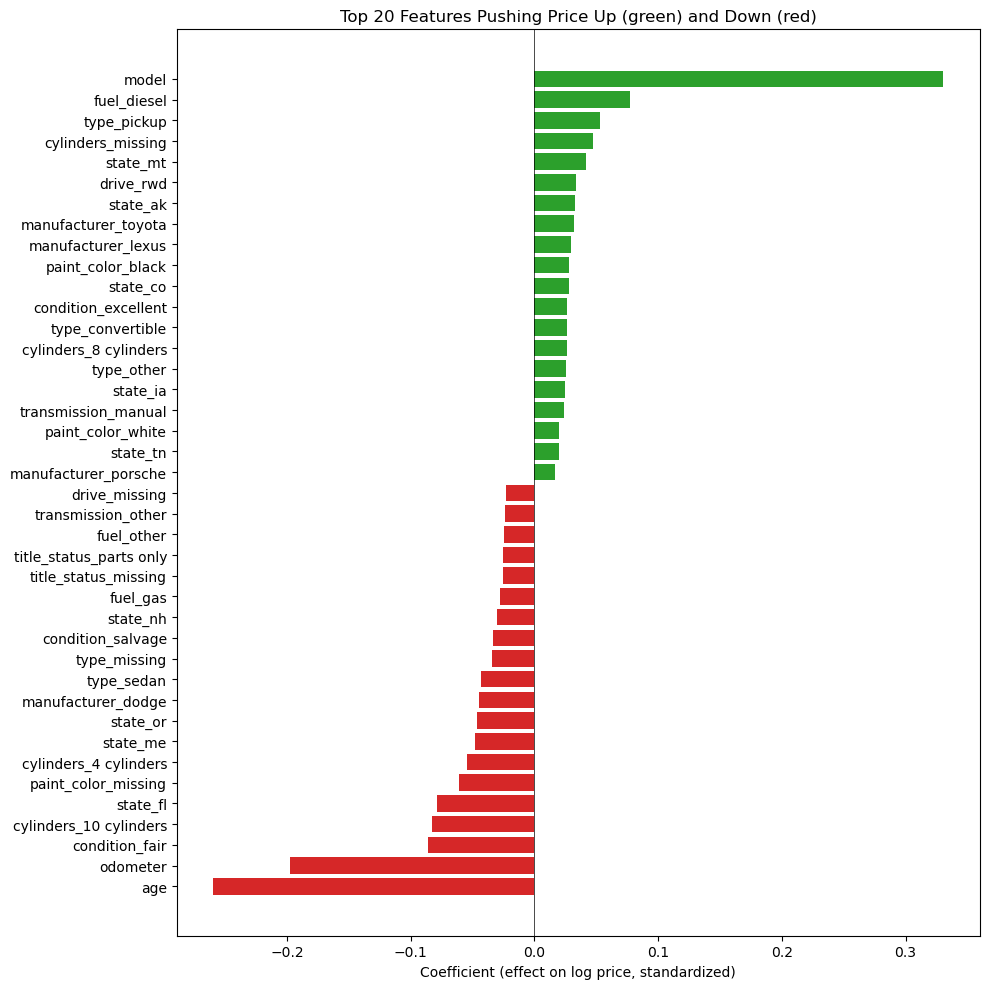

In [37]:
ridge_model = ridge_pipe.named_steps['ridge']
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': ridge_model.coef_,
}).assign(abs_coef=lambda d: d['coefficient'].abs())

top_n = 20
top_pos = coef_df.nlargest(top_n, 'coefficient')
top_neg = coef_df.nsmallest(top_n, 'coefficient')
top_features = pd.concat([top_pos, top_neg]).sort_values('coefficient')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#d62728' if c < 0 else '#2ca02c' for c in top_features['coefficient']]
ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Coefficient (effect on log price, standardized)')
ax.set_title(f'Top {top_n} Features Pushing Price Up (green) and Down (red)')
plt.tight_layout()
plt.show()


### Geographic Effects

State-level effects are present but smaller than vehicle-level effects. Some states show modest premiums (likely reflecting local supply/demand for particular vehicle types — e.g., trucks in the Mountain West), but state of listing is a second-order factor compared to vehicle attributes.

### Recommendations for Inventory Decisions

1. **Prioritize clean-title inventory.** Salvage and rebuilt vehicles trade at significant discounts. Even when the acquisition cost is low, the sale-price discount is reliable and large enough to dominate other margin considerations.
2. **Target the 0–10-year, sub-150k-mile sweet spot.** This range captures the bulk of the volume and the most predictable pricing — and benefits most from the strong age/mileage effects.
3. **Trucks and pickups are higher-margin opportunities** in the used market — they hold value better than sedans and command consistent premiums for comparable age/mileage.
4. **Be especially careful with vehicles approaching 150,000 miles.** Our analysis shows that discounts accelerate beyond this threshold, so a vehicle at 145k miles is meaningfully more salable than one at 175k miles, even though the difference seems small.
5. **Don't over-emphasize cosmetic features** like paint color. The data shows weak and inconsistent effects from paint color compared to mechanical and structural features.
6. **Be cautious with listings that have multiple missing fields.** They tend to sell at a discount even when the visible features look good — the market is reading missing data as a quality signal.

### Important Caveats for the Reader

- The model explains ~67% of price variation. The remaining variation depends on factors not in this analysis: listing photos, free-text descriptions, exact trim levels, listing recency, regional supply, and overall listing quality.
- Predictions are most accurate in the $10k–$30k range and degrade at the extremes.
- The analysis is based on Craigslist listings, which skew toward private-party and lower-margin transactions; dealer-network pricing may differ.
- The dataset reflects market conditions captured at the time of collection. Significant macro changes (interest rates, fuel prices, supply chain) may shift these effects.
- Vehicles older than ~45 years (pre-1980) were excluded from the analysis because classic-car pricing follows different dynamics than the daily-use market this report addresses.

### Suggested Next Steps

For a production pricing tool, at least one enhancement would meaningfully improve accuracy: incorporating listing-quality signals such as photo presence, description length, and listing recency. The current model is sufficient for inventory strategy decisions but should not be used as a per-vehicle pricing oracle.
Another improvement would be using clustering methods to produce different pricing models for different car classifications. This would produce several different smaller prediction models rather than one general one, which could also identify very different features that are important to the pricing of different kinds of cars.